# Notebook 02 — Experiment Tracking con MLflow

**Objetivo:** Establecer un sistema robusto de seguimiento de experimentos
para la clasificación binaria de deslizamientos en Antioquia.

**Configuración:** `configs/antioquia_deslizamientos.yaml`
**Depende de:** `01_antioquia_deslizamientos_scope.ipynb` (dataset procesado)

## Estructura de este notebook

Este notebook se divide en tres pilares, que corresponden a las tres fases
de la metodología de experiment tracking:

```
Pilar 1 — Configuración MLflow
    Preparar el entorno, definir la estructura de experimentos
    y establecer el logging automático de parámetros y métricas.

Pilar 2 — Experimentación inicial
    Evaluar múltiples algoritmos con validación cruzada estratificada.
    Registrar cada run en MLflow para comparación objetiva.

Pilar 3 — Model Registry
    Registrar el mejor modelo, asignar etiquetas y gestionar
    el ciclo de vida (Staging → Production).
```

> **Principio guía:** cada decisión de modelado queda registrada en MLflow.

---
## Pilar 1 — Configuración de MLflow

### ¿Qué vamos a registrar y por qué?

MLflow organiza el tracking en cuatro tipos de objetos:

| Objeto | Función | Ejemplo en este proyecto |
|--------|---------|--------------------------|
| `params` | Decisiones fijas del experimento | algoritmo, hiperparámetros, n_features |
| `metrics` | Resultados numéricos evaluables | AUC-ROC, F1, Recall clase 1 |
| `artifacts` | Archivos asociados al run | modelo serializado, gráficas, config |
| `tags` | Metadatos de trazabilidad | equipo, versión, tipo de run |

La jerarquía es: **Experimento → Runs**. Todos los algoritmos que evaluamos
viven bajo el mismo experimento `antioquia_deslizamientos_binario`,
lo que permite compararlos en la UI de MLflow con un solo vistazo.

## 0. Entorno y configuración

In [ ]:
import sys
from pathlib import Path

_cwd = Path().resolve()
for _p in [_cwd, *_cwd.parents]:
    if (_p / "pyproject.toml").exists():
        _root = _p
        break
else:
    _root = _cwd.parent

sys.path.insert(0, str(_root / "src"))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

from experiment.config import load_config

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 11
sns.set_theme(style="whitegrid")

cfg = load_config(project_root=_root)

print(" Librerías cargadas")
print(f"  Experimento MLflow: {cfg.mlflow.experiment_name}")
print(f"  Tracking URI      : {cfg.mlflow_tracking_uri}")

 Librerías cargadas
  Experimento MLflow: antioquia_deslizamientos_binario
  Tracking URI      : sqlite:///C:\Users\Mateo Atehortua\Documents\riesgo-deslizamientos-mlops\mlruns\mlflow.db


### 1.1 Inicializar MLflow

El backend SQLite almacena todos los runs localmente en `mlruns/mlflow.db`.
La ventaja sobre el filesystem por defecto es que SQLite permite consultas
y es más robusto en entornos colaborativos con Git.

In [2]:
# Configurar tracking URI (SQLite local)
mlflow.set_tracking_uri(cfg.mlflow_tracking_uri)

# Crear o recuperar el experimento
# Si ya existe (por haberlo creado en el Notebook 01), lo reutiliza
experiment = mlflow.set_experiment(cfg.mlflow.experiment_name)

print(f" MLflow configurado")
print(f"  Experimento ID : {experiment.experiment_id}")
print(f"  Ubicación      : {experiment.artifact_location}")
print(f"\nPara visualizar los resultados en la UI, ejecutar en terminal:")
print(f"  mlflow ui --backend-store-uri sqlite:///mlruns/mlflow.db")

 MLflow configurado
  Experimento ID : 1
  Ubicación      : file:c:/Users/Mateo Atehortua/Documents/riesgo-deslizamientos-mlops/notebooks/mlruns/1

Para visualizar los resultados en la UI, ejecutar en terminal:
  mlflow ui --backend-store-uri sqlite:///mlruns/mlflow.db


### 1.2 Cargar el dataset procesado

In [3]:
dataset_path = cfg.processed_dir / f"{cfg.geo.departamento}_deslizamientos_binario_v1.csv"

if not dataset_path.exists():
    raise FileNotFoundError(
        f"Dataset no encontrado: {dataset_path}\n"
        "Ejecuta primero el Notebook 01."
    )

df = pd.read_csv(dataset_path, low_memory=False)
FEATURES = [f for f in cfg.all_features if f in df.columns]
TARGET   = cfg.target.nombre

X = df[FEATURES]
y = df[TARGET]

print(f" Dataset cargado: {df.shape}")
print(f"  Features ({len(FEATURES)}): {FEATURES}")
print(f"  Target           : '{TARGET}'")
print(f"  Clase 1 (evento) : {y.sum():,} ({y.mean():.1%})")
print(f"  Clase 0 (no ev.) : {(~y.astype(bool)).sum():,} ({1-y.mean():.1%})")
print(f"  Ratio desbalance : 1:{(~y.astype(bool)).sum() / y.sum():.1f}")

 Dataset cargado: (47, 17)
  Features (12): ['precip_suma', 'precip_max', 'precip_media', 'precip_dias', 'n_estaciones', 'precip_lag1', 'precip_acum3m', 'precip_acum6m', 'precip_max3m', 'precip_dias3m', 'mes_sin', 'mes_cos']
  Target           : 'deslizamiento'
  Clase 1 (evento) : 43 (91.5%)
  Clase 0 (no ev.) : 4 (8.5%)
  Ratio desbalance : 1:0.1


---
## Pilar 2 — Experimentación inicial

### Estrategia de evaluación

Usamos **TimeSeriesSplit para el Cross-Validation** con 5 folds.

Con datos temporales, el CV estándar (StratifiedKFold) comete un error
fundamental: puede entrenar con datos del futuro para predecir el pasado.
En series de tiempo eso es data leakage garantizado.

TimeSeriesSplit respeta el orden cronológico: el conjunto de entrenamiento
siempre termina antes de que empiece el de validación.

```
Con 5 folds sobre ~208 semanas (2019-2022):
Fold 1: [sem 1 ··· sem 35] → valida [sem 36 ··· sem 70]
Fold 2: [sem 1 ··· sem 70] → valida [sem 71 ··· sem 105]
Fold 3: [sem 1 ··· sem 105] → valida [sem 106 ··· sem 140]
Fold 4: [sem 1 ··· sem 140] → valida [sem 141 ··· sem 175]
Fold 5: [sem 1 ··· sem 175] → valida [sem 176 ··· sem 208]

```
Cada fold amplía el entrenamiento — el modelo nunca ve el futuro.
Esto también implica dos consecuencias importantes:

1. No se puede usar `shuffle=True` — los datos deben mantenerse
   en orden cronológico estricto.
2. No se puede usar `class_weight` en la métrica de validación
   de la misma forma — algunos folds tempranos pueden tener
   muy pocos eventos positivos porque los deslizamientos tienen
   estacionalidad (más en segundo semestre en Antioquia).


### Métricas a registrar

| Métrica | Justificación |
|---------|---------------|
| `AUC-ROC` | Mide discriminación global, robusta al desbalance |
| `Recall clase 1` | Detectar deslizamientos reales (costo alto de falso negativo) |
| `Precision clase 1` | Calidad de las alertas (costo de falsa alarma) |
| `F1 clase 1` | Balance entre precision y recall |

> El **Recall** es la métrica más importante en este dominio:
> es peor no detectar un deslizamiento real (consecuencias humanas)
> que emitir una falsa alarma (costo operativo).

### 2.1 Definir el pipeline base

In [ ]:
# El pipeline encadena tres pasos en orden:
# 1. Imputación: reemplaza NaN con la mediana de cada feature
#    (robusto a outliers, adecuado para precipitaciones)
# 2. Escalado: estandariza a media=0, std=1
#    (necesario para Regresión Logística, opcional para árboles)
# 3. Clasificador: se reemplaza por cada algoritmo en el experimento

def make_pipeline(classifier) -> Pipeline:
    """
    Construye un pipeline sklearn con imputación + escalado + clasificador.

    Encapsular todo en un pipeline tiene dos ventajas críticas:
    1. Evita data leakage: la imputación y el escalado se ajustan SOLO
       con datos de entrenamiento (dentro del CV), nunca con validación.
    2. El modelo serializado incluye todos los pasos — se puede aplicar
       directamente a datos crudos en producción sin preprocessing manual.
    """
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("clf",     classifier),
    ])

# Validación cruzada estratificada — 5 folds
cv = TimeSeriesSplit(n_splits=5)

print(" Pipeline base configurado")
print("  Pasos: SimpleImputer(median) → StandardScaler → Clasificador")
print(f"  CV: TimesSeriesSplit")

 Pipeline base configurado
  Pasos: SimpleImputer(median) → StandardScaler → Clasificador
  CV: StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


### 2.2 Definir los algoritmos a evaluar

In [5]:
# Diccionario de experimentos: nombre → clasificador con sus hiperparámetros
# Cada entrada generará un run independiente en MLflow

EXPERIMENTOS = {
    # ── Baseline ──────────────────────────────────────────────────────────
    # El DummyClassifier es el punto de referencia mínimo.
    # Si un modelo real no supera este baseline, algo está mal.
    "baseline_dummy": DummyClassifier(
        strategy="stratified",
        random_state=42,
    ),

    # ── Regresión Logística ───────────────────────────────────────────────
    # Modelo lineal, interpretable. Buena primera aproximación.
    # class_weight="balanced" ajusta los pesos inversamente proporcional
    # a la frecuencia de cada clase — manejo explícito del desbalance.
    "logistic_regression": LogisticRegression(
        C=1.0,
        class_weight=cfg.target.class_weight,
        max_iter=500,
        random_state=42,
    ),

    # ── Random Forest ─────────────────────────────────────────────────────
    # Modelo ensemble basado en árboles. Robusto a features correlacionadas.
    # n_estimators=100 es un buen punto de partida; se puede aumentar.
    "random_forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        class_weight=cfg.target.class_weight,
        random_state=42,
        n_jobs=-1,
    ),

    # ── Gradient Boosting ─────────────────────────────────────────────────
    # Modelo boosting: entrena árboles secuencialmente, cada uno corrigiendo
    # los errores del anterior. Generalmente el más potente de los tres,
    # pero más propenso a overfitting con datasets pequeños.
    "gradient_boosting": GradientBoostingClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        random_state=42,
    ),
}

print(f" {len(EXPERIMENTOS)} algoritmos definidos:")
for nombre in EXPERIMENTOS:
    print(f"  - {nombre}")

 4 algoritmos definidos:
  - baseline_dummy
  - logistic_regression
  - random_forest
  - gradient_boosting


### 2.3 Ejecutar experimentos y registrar en MLflow

In [11]:
def evaluar_con_cv(pipeline: Pipeline, X: pd.DataFrame, y: pd.Series, cv) -> dict:
    """
    Ejecuta validación cruzada y retorna métricas promediadas.

    cross_validate calcula cada métrica en cada fold y devuelve arrays.
    Tomamos la media como estimador del rendimiento esperado y el std
    como indicador de estabilidad (alta std = modelo inestable).
    """
    scoring = {
        "roc_auc"   : "roc_auc",
        "f1"        : "f1",
        "precision" : "precision",
        "recall"    : "recall",
    }
    
    try:
        resultados = cross_validate(
            pipeline, X, y,
            cv=cv,
            scoring=scoring,
            n_jobs=-1,
            error_score=0.0,   # ← en lugar de NaN, usa 0 si un fold falla
        )
    except Exception as e:
        print(f"  CV falló completamente: {e}")
        return {m: 0.0 for m in [
            "auc_roc_mean", "auc_roc_std",
            "f1_mean", "f1_std",
            "precision_mean", "precision_std",
            "recall_mean", "recall_std",
        ]}
        
    def safe_mean(arr):
        vals = arr[~np.isnan(arr)]
        return float(vals.mean()) if len(vals) > 0 else 0.0

    def safe_std(arr):
        vals = arr[~np.isnan(arr)]
        return float(vals.std()) if len(vals) > 0 else 0.0
        
    resultados = cross_validate(pipeline, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    return {
        "auc_roc_mean"   : safe_mean(resultados["test_roc_auc"]),
        "auc_roc_std"    : safe_std(resultados["test_roc_auc"]),
        "f1_mean"        : safe_mean(resultados["test_f1"]),
        "f1_std"         : safe_std(resultados["test_f1"]),
        "precision_mean" : safe_mean(resultados["test_precision"]),
        "precision_std"  : safe_std(resultados["test_precision"]),
        "recall_mean"    : safe_mean(resultados["test_recall"]),
        "recall_std"     : safe_std(resultados["test_recall"]),
    }

print("Diagnóstico del dataset antes del CV:")
print(f"  Total meses   : {len(y)}")
print(f"  Clase 1       : {y.sum()} ({y.mean():.1%})")
print(f"  Clase 0       : {(y==0).sum()} ({(y==0).mean():.1%})")
print(f"  NaN en X      : {X.isnull().sum().sum()}")
print()

# Simular cómo quedarían los folds
for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), 1):
    y_train_fold = y.iloc[train_idx]
    y_val_fold   = y.iloc[val_idx]
    print(f"  Fold {fold} — train: clase1={y_train_fold.sum()} | val: clase1={y_val_fold.sum()}")

# ── Loop principal de experimentación ─────────────────────────────────────────
resultados_todos = {}

for nombre, clasificador in EXPERIMENTOS.items():
    pipeline = make_pipeline(clasificador)

    with mlflow.start_run(run_name=nombre, tags=cfg.mlflow.run_tags) as run:

        # 1. Registrar parámetros del experimento
        params_run = {
            **cfg.as_mlflow_params(),
            "algoritmo"       : nombre,
            "cv_n_splits"     : 5,
            "cv_estrategia"   : "stratified",
            "imputer_strategy": "median",
            "n_features"      : len(FEATURES),
        }
        # Agregar hiperparámetros del clasificador
        params_run.update({
            f"clf__{k}": str(v)
            for k, v in clasificador.get_params().items()
        })
        mlflow.log_params(params_run)

        # 2. Evaluar con CV
        metricas = evaluar_con_cv(pipeline, X, y, cv)

        # 3. Registrar métricas en MLflow
        mlflow.log_metrics(metricas)

        # 4. Entrenar en todo el dataset para serializar el modelo
        pipeline.fit(X, y)

        # 5. Registrar el modelo con firma (input/output schema)
        signature = infer_signature(X, pipeline.predict(X))
        mlflow.sklearn.log_model(
            pipeline,
            name="model",
            signature=signature,
            input_example=X.head(3),
        )

        resultados_todos[nombre] = {**metricas, "run_id": run.info.run_id}

    print(
        f"  [{nombre:25s}] "
        f"AUC={metricas['auc_roc_mean']:.3f}±{metricas['auc_roc_std']:.3f}  "
        f"Recall={metricas['recall_mean']:.3f}±{metricas['recall_std']:.3f}"
    )

print(f"\n {len(EXPERIMENTOS)} runs registrados en MLflow")

Diagnóstico del dataset antes del CV:
  Total meses   : 47
  Clase 1       : 43 (91.5%)
  Clase 0       : 4 (8.5%)
  NaN en X      : 0

  Fold 1 — train: clase1=34 | val: clase1=9
  Fold 2 — train: clase1=34 | val: clase1=9
  Fold 3 — train: clase1=35 | val: clase1=8
  Fold 4 — train: clase1=35 | val: clase1=8
  Fold 5 — train: clase1=34 | val: clase1=9


2026/05/05 18:45:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/05 18:46:14 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


  [baseline_dummy           ] AUC=0.441±0.003  Recall=0.883±0.007


2026/05/05 18:46:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/05 18:46:40 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


  [logistic_regression      ] AUC=0.479±0.232  Recall=0.750±0.124


2026/05/05 18:46:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/05 18:46:59 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


  [random_forest            ] AUC=0.165±0.146  Recall=1.000±0.000


2026/05/05 18:47:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/05 18:47:19 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


  [gradient_boosting        ] AUC=0.243±0.296  Recall=0.858±0.143

 4 runs registrados en MLflow


### 2.4 Comparación de resultados

In [8]:
df_resultados = pd.DataFrame(resultados_todos).T
df_resultados = df_resultados.drop(columns=["run_id"])
df_resultados = df_resultados.astype(float).round(4)
df_resultados = df_resultados.sort_values("auc_roc_mean", ascending=False)

print("Resultados de validación cruzada (5-fold estratificado):")
print("(ordenado por AUC-ROC — métrica principal)\n")
display(df_resultados[[
    "auc_roc_mean", "auc_roc_std",
    "recall_mean",  "recall_std",
    "f1_mean",      "f1_std",
]])

mejor_modelo = df_resultados.index[0]
print(f"\n→ Mejor modelo: '{mejor_modelo}'")
print(f"  AUC-ROC : {df_resultados.loc[mejor_modelo, 'auc_roc_mean']:.3f}")
print(f"  Recall  : {df_resultados.loc[mejor_modelo, 'recall_mean']:.3f}")

Resultados de validación cruzada (5-fold estratificado):
(ordenado por AUC-ROC — métrica principal)



,auc_roc_mean,auc_roc_std,recall_mean,recall_std,f1_mean,f1_std
logistic_regression,0.4792,0.2319,0.7500,0.1239,0.8083,0.0858
baseline_dummy,0.4410,0.0035,0.8833,0.0068,0.8938,0.0245
gradient_boosting,0.2431,0.2962,0.8583,0.1428,0.8735,0.0922
random_forest,0.1649,0.1459,1.0000,0.0000,0.9554,0.0225



→ Mejor modelo: 'logistic_regression'
  AUC-ROC : 0.479
  Recall  : 0.750


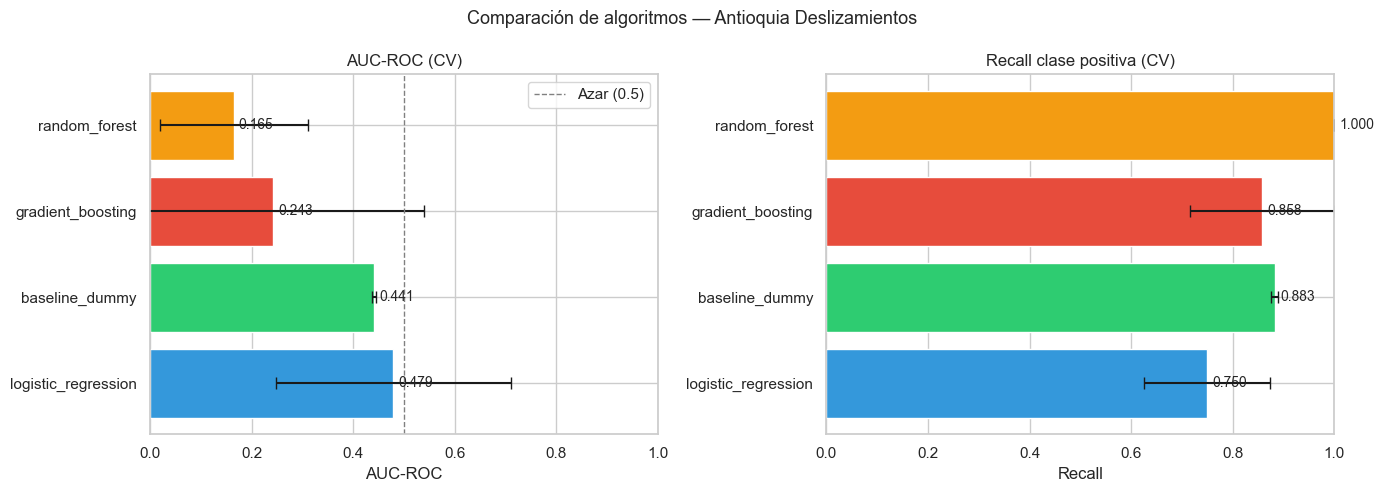

✓ Gráfica guardada y registrada en MLflow
  Ruta local: mlruns\artifacts_tmp\comparacion_modelos.png


In [10]:
# Crear directorio para artefactos temporales
artifacts_dir = _root / "mlruns" / "artifacts_tmp"
artifacts_dir.mkdir(parents=True, exist_ok=True)
grafica_path  = artifacts_dir / "comparacion_modelos.png"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

modelos  = df_resultados.index.tolist()
colores  = ["#3498db", "#2ecc71", "#e74c3c", "#f39c12"][:len(modelos)]

# AUC-ROC
auc_means = df_resultados["auc_roc_mean"].values
auc_stds  = df_resultados["auc_roc_std"].values
bars = axes[0].barh(modelos, auc_means, xerr=auc_stds,
                    color=colores, edgecolor="white", capsize=4)
axes[0].axvline(0.5, color="gray", linestyle="--", linewidth=1, label="Azar (0.5)")
axes[0].set_title("AUC-ROC (CV)")
axes[0].set_xlabel("AUC-ROC")
axes[0].legend()
axes[0].set_xlim(0, 1)
for bar, val in zip(bars, auc_means):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                 f"{val:.3f}", va="center", fontsize=10)

# Recall
rec_means = df_resultados["recall_mean"].values
rec_stds  = df_resultados["recall_std"].values
bars2 = axes[1].barh(modelos, rec_means, xerr=rec_stds,
                     color=colores, edgecolor="white", capsize=4)
axes[1].set_title("Recall clase positiva (CV)")
axes[1].set_xlabel("Recall")
axes[1].set_xlim(0, 1)
for bar, val in zip(bars2, rec_means):
    axes[1].text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                 f"{val:.3f}", va="center", fontsize=10)

plt.suptitle("Comparación de algoritmos — Antioquia Deslizamientos", fontsize=13)
plt.tight_layout()

# Guardar en ruta del proyecto (no en /tmp/)
fig.savefig(grafica_path, dpi=120, bbox_inches="tight")
plt.show()

# Registrar en el run del mejor modelo
with mlflow.start_run(run_id=resultados_todos[mejor_modelo]["run_id"], nested=True):
    mlflow.log_artifact(str(grafica_path))

print(f"✓ Gráfica guardada y registrada en MLflow")
print(f"  Ruta local: {grafica_path.relative_to(_root)}")

---
## Pilar 3 — Model Registry

### ¿Qué es el Model Registry de MLflow?

El Model Registry es una capa por encima del tracking que gestiona
el **ciclo de vida de los modelos**.

```
Experimentación (runs) → Registro → Staging → Production → Archived
                                       ↑            ↑
                                  Validación    Despliegue
```

Sin el registry, el equipo no sabe cuál modelo está en producción,
cuándo fue entrenado ni con qué datos. El registry hace eso trazable
y auditable.

### 3.1 Registrar el mejor modelo

In [ ]:
from mlflow.tracking import MlflowClient

client = MlflowClient(tracking_uri=cfg.mlflow_tracking_uri)

# Nombre del modelo registrado en el registry
MODEL_REGISTRY_NAME = f"{cfg.geo.departamento}_deslizamiento_binario"

# URI del artefacto del mejor run
best_run_id = resultados_todos[mejor_modelo]["run_id"]
model_uri   = f"runs:/{best_run_id}/model"

# Registrar en el Model Registry
# Si el modelo ya existe, crea una nueva versión automáticamente
result = mlflow.register_model(model_uri=model_uri, name=MODEL_REGISTRY_NAME)

print(f" Modelo registrado en el registry")
print(f"  Nombre   : {MODEL_REGISTRY_NAME}")
print(f"  Versión  : {result.version}")
print(f"  Run ID   : {best_run_id}")
print(f"  Algoritmo: {mejor_modelo}")

### 3.2 Agregar tags de trazabilidad

In [ ]:
# Los tags documentan el contexto de cada versión del modelo.
# Son fundamentales para auditoría y para que el equipo entienda
# qué versión está en cada estado del ciclo de vida.

client.set_model_version_tag(
    name    = MODEL_REGISTRY_NAME,
    version = result.version,
    key     = "algoritmo",
    value   = mejor_modelo,
)
client.set_model_version_tag(
    name    = MODEL_REGISTRY_NAME,
    version = result.version,
    key     = "auc_roc_cv",
    value   = f"{df_resultados.loc[mejor_modelo, 'auc_roc_mean']:.4f}",
)
client.set_model_version_tag(
    name    = MODEL_REGISTRY_NAME,
    version = result.version,
    key     = "recall_cv",
    value   = f"{df_resultados.loc[mejor_modelo, 'recall_mean']:.4f}",
)
client.set_model_version_tag(
    name    = MODEL_REGISTRY_NAME,
    version = result.version,
    key     = "dataset_version",
    value   = "v1",
)
client.set_model_version_tag(
    name    = MODEL_REGISTRY_NAME,
    version = result.version,
    key     = "entrenado_con",
    value   = f"{cfg.geo.departamento} {cfg.periodo.anio_inicio}-{cfg.periodo.anio_fin}",
)

print(f"✓ Tags agregados a la versión {result.version}")

### 3.3 Transición de estado: None → Staging

In [ ]:
# En MLflow, los estados del ciclo de vida son:
# None (recién registrado) → Staging (en validación) → Production → Archived
#
# Mover a Staging significa: "este modelo pasó la evaluación inicial
# y está listo para validación adicional antes de producción".

AUC_MINIMO_STAGING = 0.65

auc_del_mejor = df_resultados.loc[mejor_modelo, "auc_roc_mean"]

if auc_del_mejor >= AUC_MINIMO_STAGING:
    client.transition_model_version_stage(
        name    = MODEL_REGISTRY_NAME,
        version = result.version,
        stage   = "Staging",
        archive_existing_versions=False,
    )
    print(f"✓ Versión {result.version} promovida a Staging")
    print(f"  AUC-ROC ({auc_del_mejor:.3f}) ≥ umbral mínimo ({AUC_MINIMO_STAGING})")
else:
    print(f"✗ AUC-ROC ({auc_del_mejor:.3f}) < umbral mínimo ({AUC_MINIMO_STAGING})")
    print(f"  El modelo no cumple los criterios para Staging.")
    print(f"  Acción recomendada: revisar features o ajustar hiperparámetros.")

### 3.4 Consultar el estado del registry

In [ ]:
# Verificar el estado actual del registry — útil para el equipo
print(f"Estado actual del Model Registry: '{MODEL_REGISTRY_NAME}'")
print("=" * 55)

for version in client.search_model_versions(f"name='{MODEL_REGISTRY_NAME}'"):
    tags = {t.key: t.value for t in version.tags}
    print(f"\n  Versión : {version.version}")
    print(f"  Estado  : {version.current_stage}")
    print(f"  Run ID  : {version.run_id[:8]}...")
    print(f"  Tags    : {tags}")

In [ ]:
print("=" * 60)
print("RESUMEN — EXPERIMENT TRACKING")
print("=" * 60)
print(f"  Experimento MLflow : {cfg.mlflow.experiment_name}")
print(f"  Algoritmos evaluados: {len(EXPERIMENTOS)}")
print(f"  Mejor modelo       : {mejor_modelo}")
print(f"  AUC-ROC (CV)       : {df_resultados.loc[mejor_modelo, 'auc_roc_mean']:.3f}")
print(f"  Recall  (CV)       : {df_resultados.loc[mejor_modelo, 'recall_mean']:.3f}")
print(f"  Registry           : {MODEL_REGISTRY_NAME} v{result.version}")
print(f"  Estado             : {client.get_model_version(MODEL_REGISTRY_NAME, result.version).current_stage}")
print(f"\n  Para ver la UI:")
print(f"  mlflow ui --backend-store-uri sqlite:///mlruns/mlflow.db")
print("=" * 60)